# F1 Championship Prediction — Exploratory Data Analysis
End-to-end walkthrough: data loading → EDA → feature analysis → model training → prediction evaluation.

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'SRC'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

RAW  = os.path.join('..', 'Data', 'raw data')
PROC = os.path.join('..', 'Data', 'processed')

Matplotlib is building the font cache; this may take a moment.


## 1. Load Raw Data

In [2]:
races        = pd.read_csv(f'{RAW}/races.csv')
results      = pd.read_csv(f'{RAW}/results.csv')
drivers      = pd.read_csv(f'{RAW}/drivers.csv')
constructors = pd.read_csv(f'{RAW}/constructors.csv')
status       = pd.read_csv(f'{RAW}/status.csv')
driver_standings = pd.read_csv(f'{RAW}/driver_standings.csv')

print('races:       ', races.shape)
print('results:     ', results.shape)
print('drivers:     ', drivers.shape)
print('status:      ', status.shape)
results.head()

races:        (1125, 18)
results:      (26759, 18)
drivers:      (861, 9)
status:       (139, 2)


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1


## 2. Seasons Overview

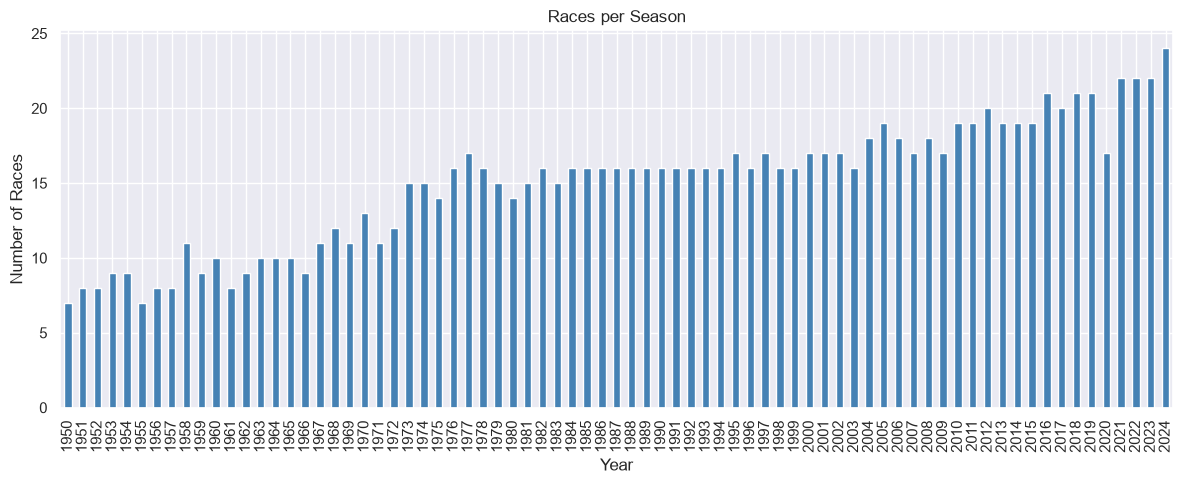

Dataset covers 1950 to 2024 — 75 seasons


In [3]:
races_per_year = races.groupby('year')['raceId'].count()
races_per_year.plot(kind='bar', title='Races per Season', color='steelblue')
plt.xlabel('Year')
plt.ylabel('Number of Races')
plt.tight_layout()
plt.show()
print(f'Dataset covers {races["year"].min()} to {races["year"].max()} — {races["year"].nunique()} seasons')

## 3. DNF Analysis

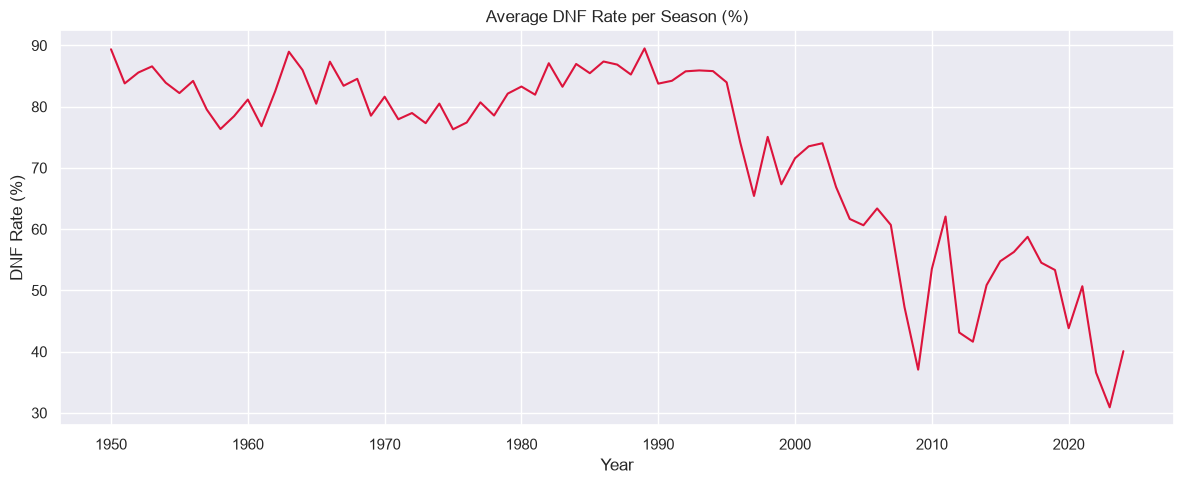

In [4]:
finished_ids = status.loc[status['status'] == 'Finished', 'statusId'].values
results['dnf'] = (~results['statusId'].isin(finished_ids)).astype(int)

df = results.merge(races[['raceId','year']], on='raceId', how='left')
dnf_by_year = df.groupby('year')['dnf'].mean() * 100

dnf_by_year.plot(title='Average DNF Rate per Season (%)', color='crimson')
plt.ylabel('DNF Rate (%)')
plt.xlabel('Year')
plt.tight_layout()
plt.show()

## 4. Points Distribution — Modern Era (2010+)

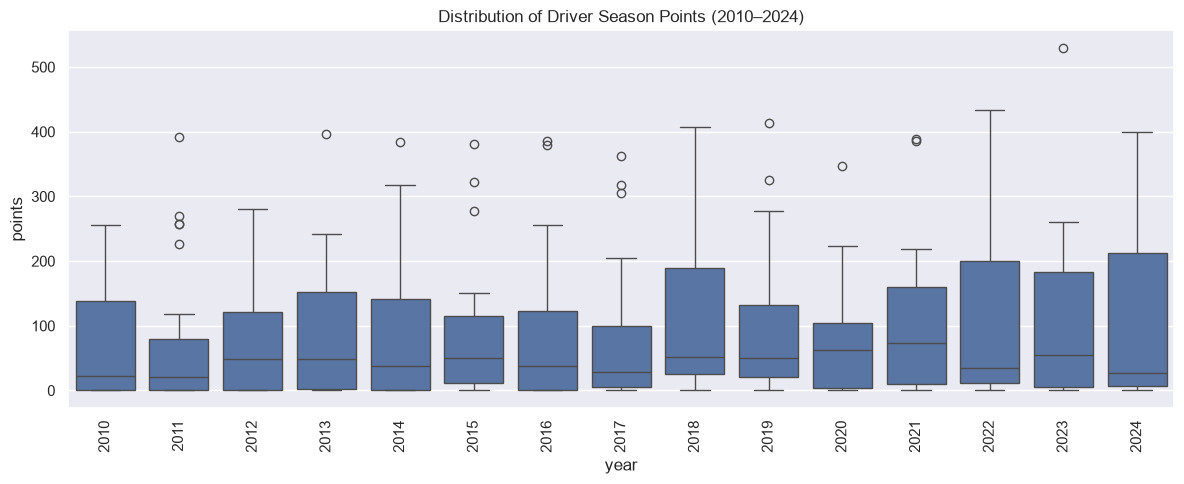

In [5]:
modern = df[df['year'] >= 2010].copy()
modern['points'] = pd.to_numeric(modern['points'], errors='coerce').fillna(0)

season_pts = modern.groupby(['year','driverId'])['points'].sum().reset_index()

sns.boxplot(data=season_pts, x='year', y='points')
plt.xticks(rotation=90)
plt.title('Distribution of Driver Season Points (2010–2024)')
plt.tight_layout()
plt.show()

## 5. Top 10 Most Successful Drivers (by wins)

C:\Users\91829\AppData\Local\Temp\ipykernel_22028\1787974298.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=wins, x='wins', y='driver', palette='viridis')


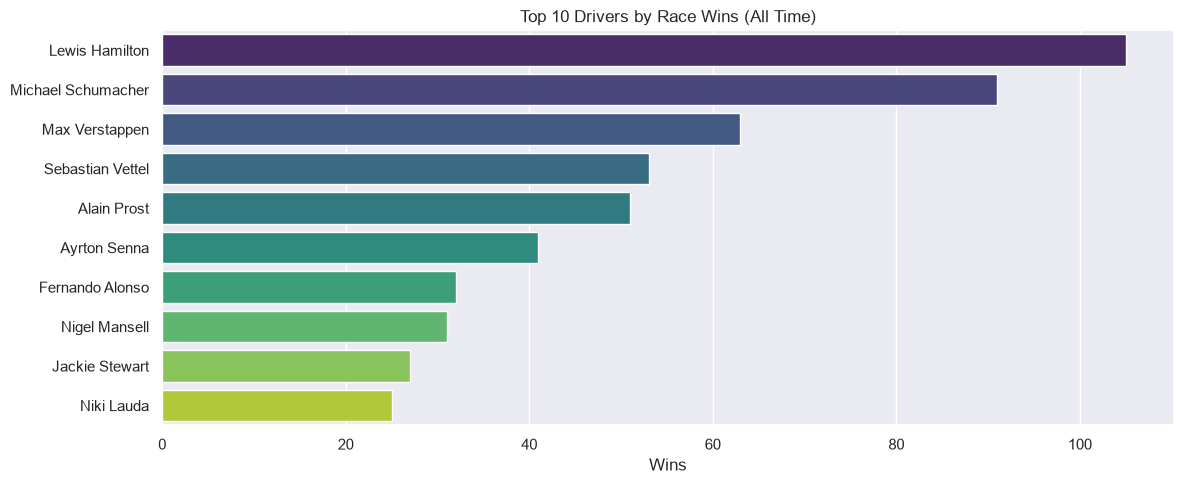

In [6]:
results['positionOrder'] = pd.to_numeric(results['positionOrder'], errors='coerce')
wins = results[results['positionOrder'] == 1].groupby('driverId').size().reset_index(name='wins')
wins = wins.merge(drivers[['driverId','forename','surname']], on='driverId')
wins['driver'] = wins['forename'] + ' ' + wins['surname']
wins = wins.nlargest(10, 'wins')

sns.barplot(data=wins, x='wins', y='driver', palette='viridis')
plt.title('Top 10 Drivers by Race Wins (All Time)')
plt.xlabel('Wins')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 6. Feature Correlation Heatmap

Features shape: (3553, 27)


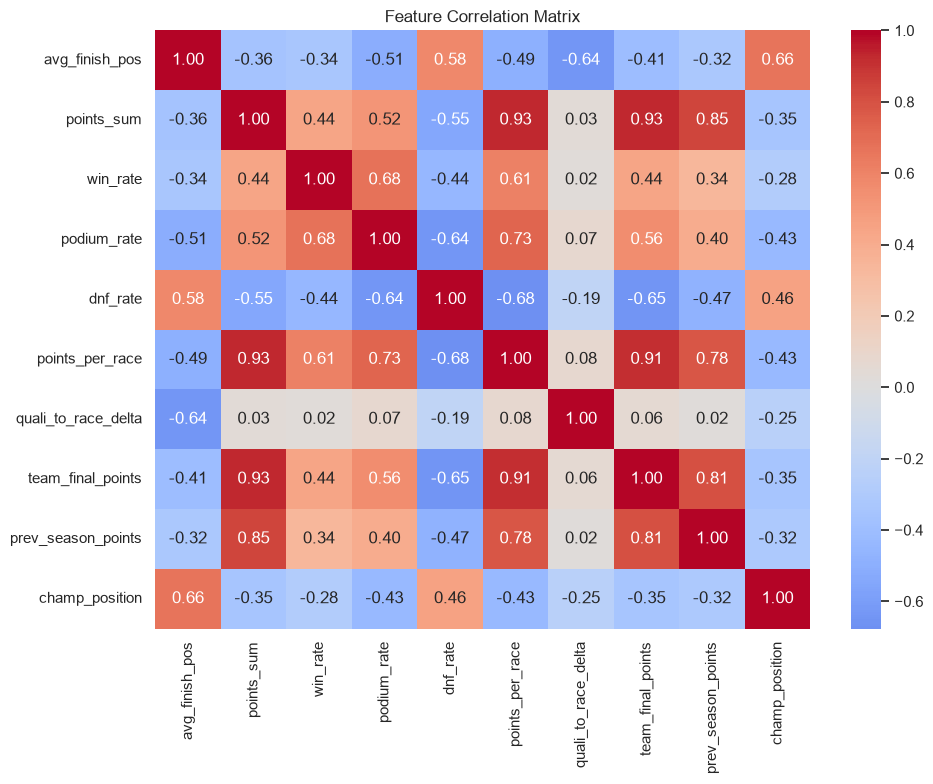

In [7]:
features = pd.read_csv(f'{PROC}/features.csv')
print(f'Features shape: {features.shape}')

cols_of_interest = [
    'avg_finish_pos', 'points_sum', 'win_rate', 'podium_rate',
    'dnf_rate', 'points_per_race', 'quali_to_race_delta',
    'team_final_points', 'prev_season_points', 'champ_position'
]
corr = features[cols_of_interest].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 7. Train Models

In [8]:
from model import train_model
reg_model, clf_model = train_model()

Loaded 3534 rows across 75 seasons (1950–2024)

── Regression ────────────────────────────────────────────────
  Ridge                | CV RMSE: 10.395 | R²: 0.769 | Spearman: 0.898
  Random Forest        | CV RMSE: 8.789 | R²: 0.847 | Spearman: 0.951
  Gradient Boosting    | CV RMSE: 8.975 | R²: 0.854 | Spearman: 0.949

  Best: Random Forest (Spearman=0.951)

  Top 10 features:
points_sum             0.266095
points_per_race        0.247010
avg_finish_pos         0.173354
team_final_position    0.164472
std_finish_pos         0.026965
avg_grid_pos           0.026899
prev_season_points     0.023409
prev_season_avg_pos    0.020578
quali_to_race_delta    0.019210
races_started          0.015752

── Classification ────────────────────────────────────────────
  Tier Classifier | CV Acc: 0.851 | Test Acc: 0.849

  Saved regression model → c:\Users\91829\OneDrive\Documents\GitHub\f1-championship-prediction\models\championship_model.pkl
  Saved tier classifier  → c:\Users\91829\OneDrive\Docum

## 8. Predict & Evaluate — 2023 Season

In [9]:
from predict import predict_championship
results_2023 = predict_championship(2023)


── 2023 Championship Prediction ─────────────────────────────
  Spearman rank correlation vs actual: 0.999

 Predicted Rank           Driver           Team Predicted Tier  Predicted Score  Actual Position  Actual Points
              1   Max Verstappen       Red Bull       Champion             1.11              1.0          575.0
              2     Sergio Pérez       Red Bull         Podium             3.22              2.0          285.0
              3   Lewis Hamilton       Mercedes          Top 5             3.97              3.0          234.0
              4  Fernando Alonso   Aston Martin          Top 5             4.09              4.0          206.0
              5  Charles Leclerc        Ferrari          Top 5             4.73              5.0          206.0
              6     Lando Norris        McLaren         Top 10             5.16              6.0          205.0
              7     Carlos Sainz        Ferrari         Top 10             6.31              7.0          2

## 9. Predicted vs Actual — Scatter Plot

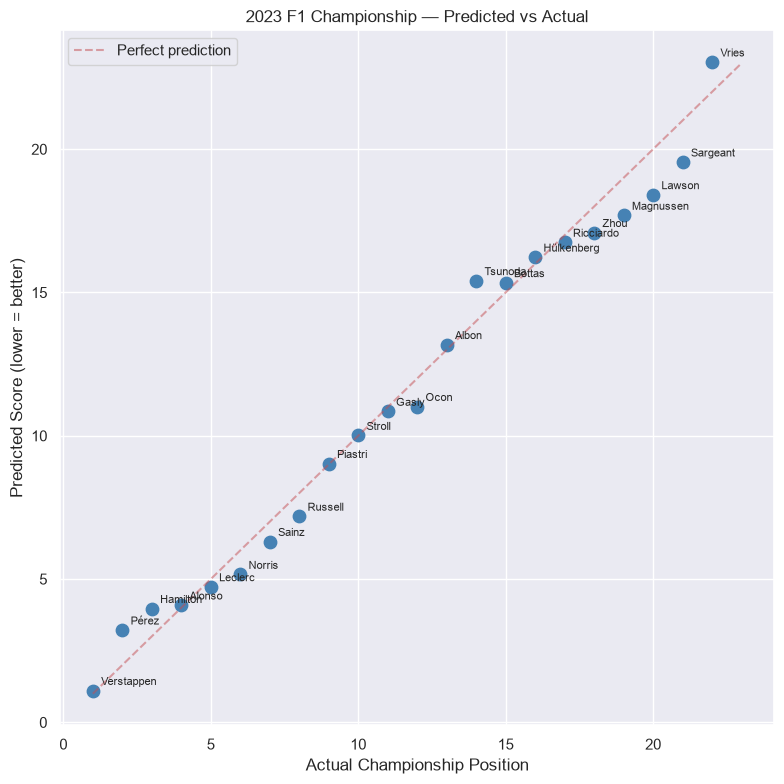

In [10]:
valid = results_2023.dropna(subset=['Actual Position'])

plt.figure(figsize=(8, 8))
plt.scatter(valid['Actual Position'], valid['Predicted Score'], color='steelblue', s=80)

for _, row in valid.iterrows():
    plt.annotate(row['Driver'].split()[-1],
                 (row['Actual Position'], row['Predicted Score']),
                 textcoords='offset points', xytext=(6, 4), fontsize=8)

# Perfect prediction line
lims = [1, int(valid['Actual Position'].max()) + 1]
plt.plot(lims, lims, 'r--', alpha=0.5, label='Perfect prediction')

plt.xlabel('Actual Championship Position')
plt.ylabel('Predicted Score (lower = better)')
plt.title('2023 F1 Championship — Predicted vs Actual')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Feature Importance

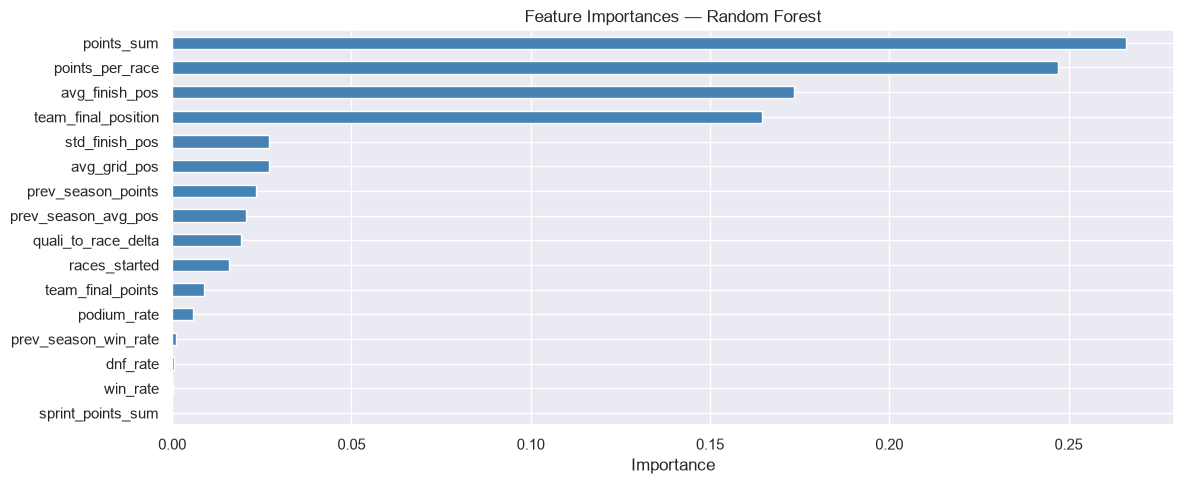

In [11]:
FEATURE_COLUMNS = [
    'avg_finish_pos','std_finish_pos','races_started','points_sum',
    'avg_grid_pos','win_rate','podium_rate','dnf_rate','points_per_race',
    'quali_to_race_delta','sprint_points_sum','team_final_points',
    'team_final_position','prev_season_points','prev_season_avg_pos','prev_season_win_rate'
]
imp = pd.Series(reg_model.feature_importances_, index=FEATURE_COLUMNS).sort_values()

imp.plot(kind='barh', title='Feature Importances — Random Forest', color='steelblue')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()